# Итоговый проект по дисциплине «Анализ данных на Python»

## Исследование эффективности вакцинации в борьбе с COVID-19

Состав команды: Колесников Андрей, Шатунова Светлана, Швецов Илья

---

## Распределение обязанностей в команде

- Андрей - Этап 1 (сбор данных), Этап 2 (очистка и предобработка), гипотеза H1.
- Илья - Этап 3 (разведочный анализ, EDA), гипотезы H2, H3, H6.
- Света - Этап 6 (экономика, API Всемирного банка, гипотеза H4), Этап 7 (лидеры и итоговые выводы).

Этап 5 (анализ временных рядов) и проверка Н5 - все

> Пометки об ответственном за каждый раздел продублированы ниже по тексту.

## Введение

### Актуальность и постановка задачи

Пандемия COVID-19 - крупнейший за столетие глобальный кризис здравоохранения, и массовая
вакцинация стала главным инструментом, с помощью которого человечество переломило её ход.
Цель нашего исследования - на открытых данных проверить, насколько вакцинация измеримо
повлияла на исходы пандемии: снизилась ли летальность после старта прививочных кампаний,
кто из стран оказался «лидером» в борьбе с вирусом и какие внешние факторы (богатство страны,
возраст населения, система здравоохранения, жёсткость ограничений) объясняют различия между
странами.

### Исследовательские вопросы

1. Снизилась ли летальность после старта массовой вакцинации по сравнению с довакцинным периодом?
2. Кто является «лидером» в борьбе с пандемией и как корректно определить понятие «лидер»?
3. Связан ли уровень вакцинации со смертностью на душу населения между странами?
4. Какие внешние факторы объясняют различия в исходах между странами?
5. Как пандемия и скорость вакцинации сказались на экономике?

### Гипотезы

Под каждую гипотезу заранее зафиксирован статистический инструмент проверки -
это позволит на этапе анализа двигаться строго и воспроизводимо.

| № | Гипотеза | Метод проверки |
|---|----------|----------------|
| **H1** | После начала массовой вакцинации летальность значимо ниже, чем до неё | Сравнение двух периодов: парный t-критерий / критерий Манна–Уитни |
| **H2** | Чем выше охват вакцинацией, тем ниже смертность на 100 тыс. населения | Корреляция Пирсона/Спирмена + линейная регрессия |
| **H3** | Богатые страны (выше ВВП на душу) вакцинировались быстрее | Корреляция / линейная регрессия |
| **H4** | Страны с высоким охватом вакцинацией быстрее восстановили экономику | Корреляция охвата с динамикой ВВП |
| **H5** | Случаи и смерти имеют выраженную сезонность (зимние волны) | Разложение временного ряда на тренд и сезонность |
| **H6** | Возраст населения сильно влияет на смертность, но вакцинация смягчает эффект | Множественная регрессия / частные корреляции |

### План работы

- Этап 1. Сбор данных - загрузка датасета Our World in Data, первичный осмотр
- Этап 2. Очистка и предобработка - отсев агрегатов, пропуски, типы, выбросы, новые признаки
- Этап 3. Разведочный анализ (EDA) - описательные статистики, распределения
- Этап 4. Проверка гипотез - статистические тесты H1–H6
- Этап 5. Анализ временных рядов - тренд, сезонность, прогноз
- Этап 6. Экономический блок - влияние на ВВП
- Этап 7. Визуализация и выводы

Усложнения (9–10 баллов): анализ временных рядов (тренд + сезонность) и оформление проекта на GitHub.

>  **Ответственный: Андрей** - Этап 1. Сбор данных

---
# Этап 1. Сбор данных

### 1.1. Источник данных

Основной источник – Our World in Data (OWID), проект, агрегирующий данные по COVID-19 из
официальных первоисточников. Выбор обусловлен тем, что OWID объединяет в одной таблице:

- эпидемиологические показатели (случаи, смерти) – из дашборда ВОЗ;
- данные вакцинации – из официальных отчётов стран;
- социально-экономические и демографические переменные (ВВП на душу, медианный возраст,
  число больничных коек и т.д.) – из данных ООН, Всемирного банка и др.;
- индекс жёсткости госограничений `stringency_index` – из проекта Oxford (OxCGRT);
- избыточную смертность `excess_mortality` – более «честную» метрику, не зависящую от
  методики подсчёта ковидных смертей.



In [85]:
%pip install pandas numpy matplotlib seaborn scipy statsmodels requests

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
import os
import urllib.request
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Версии:")
print("  pandas:", pd.__version__)
print("  numpy :", np.__version__)

Версии:
  pandas: 3.0.3
  numpy : 2.4.6


In [87]:
RAW_URL = ("https://raw.githubusercontent.com/owid/covid-19-data/"
           "master/public/data/owid-covid-data.csv")
LOCAL = "owid-covid-data.csv"

urllib.request.urlretrieve(RAW_URL, LOCAL)
print("Готово.")

df = pd.read_csv(LOCAL, low_memory=False)
print("Датасет загружен. Размер:", df.shape, "(строк, колонок)")

Готово.
Датасет загружен. Размер: (429435, 67) (строк, колонок)


### 1.2. Первичный осмотр структуры

Смотрим на размер таблицы, временной охват и первые строки, чтобы понять, с чем работаем.
Каждая строка датасета - это одна страна в один конкретный день.

In [88]:
print("Строк:", df.shape[0])
print("Колонок:", df.shape[1])
print("Период наблюдений:", df["date"].min(), "–", df["date"].max())
print("Уникальных значений location:", df["location"].nunique())

df[["iso_code", "continent", "location", "date",
    "total_cases", "total_deaths", "people_fully_vaccinated"]].head()

Строк: 429435
Колонок: 67
Период наблюдений: 2020-01-01 – 2024-08-14
Уникальных значений location: 255


,iso_code,continent,location,date,total_cases,total_deaths,people_fully_vaccinated
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN


### 1.3. Разделение «настоящих стран» и агрегатов

В OWID наряду со странами присутствуют агрегаты: мир целиком, континенты, группы стран по
уровню дохода, а также отдельные регионы. Все они помечены кодом
`iso_code`, начинающимся с префикса `OWID_`.

Если не отделить агрегаты, они исказят все межстрановые
сравнения и корреляции (например, строка «World» по населению на порядки больше любой страны).
Поэтому уже на этапе сбора фиксируем, как их отличать.

In [89]:
is_aggregate = df["iso_code"].astype(str).str.startswith("OWID_")

aggregates = sorted(df.loc[is_aggregate, "location"].unique())
print("Найдено агрегатов (не стран):", len(aggregates))
print(aggregates)

n_countries = df.loc[~is_aggregate, "location"].nunique()
print("\nНастоящих стран (без агрегатов):", n_countries)

Найдено агрегатов (не стран): 18
['Africa', 'Asia', 'England', 'Europe', 'European Union (27)', 'High-income countries', 'Kosovo', 'Low-income countries', 'Lower-middle-income countries', 'North America', 'Northern Cyprus', 'Northern Ireland', 'Oceania', 'Scotland', 'South America', 'Upper-middle-income countries', 'Wales', 'World']

Настоящих стран (без агрегатов): 237


### 1.4. Ключевые колонки и анализ пропусков

Проверяем, что все нужные для проверки наших гипотез переменные присутствуют, и оцениваем
долю пропусков по каждой.

In [90]:
key_cols = {
    "Идентификаторы / время": ["iso_code", "continent", "location", "date", "population"],
    "Эпидемиология":          ["total_cases", "new_cases", "total_deaths", "new_deaths",
                                "total_cases_per_million", "total_deaths_per_million"],
    "Вакцинация":             ["people_vaccinated", "people_fully_vaccinated",
                                "total_vaccinations", "people_fully_vaccinated_per_hundred"],
    "Внешние факторы":        ["stringency_index", "excess_mortality", "gdp_per_capita",
                                "median_age", "aged_65_older", "hospital_beds_per_thousand",
                                "human_development_index", "life_expectancy"],
}

print("Проверка наличия колонок и доли пропусков:\n")
for group, cols in key_cols.items():
    print(f"{group}")
    for c in cols:
        if c in df.columns:
            na_pct = df[c].isna().mean() * 100
            print(f"   {c:42s} есть, пропусков: {na_pct:5.1f}%")
        else:
            print(f"   {c:42s} отсутствует")
    print()

Проверка наличия колонок и доли пропусков:

Идентификаторы / время
   iso_code                                   есть, пропусков:   0.0%
   continent                                  есть, пропусков:   6.2%
   location                                   есть, пропусков:   0.0%
   date                                       есть, пропусков:   0.0%
   population                                 есть, пропусков:   0.0%

Эпидемиология
   total_cases                                есть, пропусков:   4.1%
   new_cases                                  есть, пропусков:   4.5%
   total_deaths                               есть, пропусков:   4.1%
   new_deaths                                 есть, пропусков:   4.4%
   total_cases_per_million                    есть, пропусков:   4.1%
   total_deaths_per_million                   есть, пропусков:   4.1%

Вакцинация
   people_vaccinated                          есть, пропусков:  81.1%
   people_fully_vaccinated                    есть, пропусков:  81

### 1.5. Причина пропусков в вакцинации и избыточной смертности

Высокая доля пропусков в части колонок - это структурная особенность
данных.

- Вакцинация. Прививочные кампании стартовали лишь в декабре 2020 – почти
  целый год наблюдений (весь 2020-й) физически не мог содержать данных о вакцинации. Кроме того,
  страны публикуют кумулятивные цифры нерегулярно (не каждый день), поэтому между отчётными
  датами стоят пропуски.
- Избыточная смертность. Это понедельная метрика, доступная лишь для части
  стран. Поэтому она пригодна как проверка на подвыборке, а не как основной показатель.
- Индекс жёсткости. Доступен не для всех стран и завершается в 2022 году.

Далее посмотрим с какой даты начинается ненулевая смерность.

In [91]:
vacc = df.loc[df["people_fully_vaccinated"].notna(), "date"]
print("Первая дата с данными о полной вакцинации:", vacc.min())
print("Последняя дата с данными о полной вакцинации:", vacc.max())

countries_only = df.loc[~df["iso_code"].astype(str).str.startswith("OWID_")]
n_excess = countries_only.loc[countries_only["excess_mortality"].notna(),
                              "location"].nunique()
print(f"\nСтран с данными по избыточной смертности: {n_excess} "
      f"из {countries_only['location'].nunique()}")

after = df[df["date"] >= "2021-06-01"]
na_after = after["people_fully_vaccinated"].isna().mean() * 100
print(f"\nПропуски 'people_fully_vaccinated' с июня 2021 (а не за весь период): "
      f"{na_after:.1f}%")
print("(заметно меньше – подтверждает, что пропуски в основном структурные)")

Первая дата с данными о полной вакцинации: 2020-12-13
Последняя дата с данными о полной вакцинации: 2024-08-14

Стран с данными по избыточной смертности: 125 из 237

Пропуски 'people_fully_vaccinated' с июня 2021 (а не за весь период): 77.4%
(заметно меньше – подтверждает, что пропуски в основном структурные)


### Промежуточные выводы по Этапу 1

1. Загружен датасет Our World in Data: 429 435 строк на 67 колонок, период
   01.01.2020 – 14.08.2024, формат «страна-день».
2. В данных 237 настоящих стран и 18 агрегатов (мир, континенты, группы по доходу,
   отдельные регионы), помеченных префиксом `OWID_`.
3. Все 24 ключевые переменные присутствуют – эпидемиология, вакцинация и внешние факторы.
4. Высокие доли пропусков в вакцинации и избыточной смертности – структурные (поздний старт
   прививок, нерегулярная отчётность, ограниченное покрытие). 

>  **Ответственный: Андрей** - Этап 2. Очистка и предобработка

---
# Этап 2. Очистка и предобработка данных

На данном этапе определим агрегаторы, приведем типы данных, обработаем пропущенные значения, в конечном итоге сформировав читые наборы данные, которые будут использованы для дальнейшей обработки.

### 2.1. Отделение агрегатов от стран

В данных присутствуют агрегаты с префиксом `OWID_` в `iso_code`
(мир, континенты, группы по доходу, отдельные регионы). Для межстранового анализа их нужно
исключить, иначе они исказят сравнения. При этом строку «World» мы сохраняем отдельно.

In [92]:
is_aggregate = df["iso_code"].astype(str).str.startswith("OWID_")

world = df[df["location"] == "World"].copy()
countries = df[~is_aggregate].copy()

print("Глобальный ряд 'World' сохранён отдельно:", world.shape)
print("Осталось стран/территорий после отсева агрегатов:", countries["location"].nunique())

Глобальный ряд 'World' сохранён отдельно: (1684, 67)
Осталось стран/территорий после отсева агрегатов: 237


### 2.2. Фильтрация состава стран

Среди 237 «стран» OWID - не только государства-члены ООН, но и зависимые территории
(Гонконг, Гренландия, заморские территории и т.п.). Многие из них крошечные и имеют
неполную статистику. Поэтому мы оставляем
только содержательную выборку по двум критериям:

- население больше 1 000 000 человек;
- заполнены ключевые внешние факторы - ВВП на душу и медианный возраст;
- есть ненулевые зарегистрированные смерти от COVID. Этот критерий отсекает страны с
  отсутствующей статистикой смертности: например, Гонконг и Туркменистан.
  Без этого фильтра эти страны попали бы в лидеры с нулевой смертностью и исказили выводы.

In [93]:
pop_by_country = countries.groupby("location")["population"].max()
big_enough = set(pop_by_country[pop_by_country > 1_000_000].index)

need = ["gdp_per_capita", "median_age"]
has_socio = countries.groupby("location")[need].apply(lambda g: g.notna().any().all())
with_socio = set(has_socio[has_socio].index)

deaths_by_country = countries.groupby("location")["total_deaths"].max()
has_deaths = set(deaths_by_country[deaths_by_country > 0].index)

keep_countries = big_enough & with_socio & has_deaths
print(f"Население > 1 млн:                 {len(big_enough)} стран")
print(f"С заполненными ВВП и возрастом:     {len(with_socio)} стран")
print(f"С ненулевыми смертями:             {len(has_deaths)} стран")
print(f"Итоговая выборка (все три условия): {len(keep_countries)} стран")
print(f"Исключены без статистики смертности:",
      sorted((big_enough & with_socio) - has_deaths))

d = countries[countries["location"].isin(keep_countries)].copy()
print("\nРазмер рабочей выборки:", d.shape)

Население > 1 млн:                 159 стран
С заполненными ВВП и возрастом:     184 стран
С ненулевыми смертями:             225 стран
Итоговая выборка (все три условия): 152 стран
Исключены без статистики смертности: ['Hong Kong', 'Turkmenistan']

Размер рабочей выборки: (255525, 67)


### 2.3. Приведение типов данных

Столбец `date` хранится как текст - переводим его в полноценный тип `datetime`, чтобы
корректно работать со временем. Сразу сортируем данные по стране и дате. Это обязательное условие для корректной протяжки значений и
расчёта скользящих средних на следующих шагах.

In [94]:
d["date"] = pd.to_datetime(d["date"])
d = d.sort_values(["location", "date"]).reset_index(drop=True)

print("Тип столбца date:", d["date"].dtype)
print("Диапазон дат:", d["date"].min().date(), "–", d["date"].max().date())

Тип столбца date: datetime64[us]
Диапазон дат: 2020-01-01 – 2024-08-14


### 2.4. Поиск и обработка выбросов

Известный артефакт ковид-статистики - отрицательные дневные приросты случаев и смертей.
Они возникают, когда страна задним числом корректирует завышенные данные. Нужно проверить нашу выборку на такие значения.

In [95]:
neg_cases = (d["new_cases"] < 0).sum()
neg_deaths = (d["new_deaths"] < 0).sum()
print(f"Отрицательных значений new_cases:  {neg_cases}")
print(f"Отрицательных значений new_deaths: {neg_deaths}")

d["new_cases"] = d["new_cases"].clip(lower=0)
d["new_deaths"] = d["new_deaths"].clip(lower=0)
print("\nПрименён clip(lower=0) как страховка на случай будущих коррекций.")

Отрицательных значений new_cases:  0
Отрицательных значений new_deaths: 0

Применён clip(lower=0) как страховка на случай будущих коррекций.


### 2.5. Обработка пропущенных значений

Основные пропуски - структурные:

- Вакцинация. Страны публикуют кумулятивные показатели нерегулярно, а до декабря 2020
  вакцин не существовало. Поэтому корректная стратегия - протяжка последнего известного
  значения внутри каждой страны , а оставшиеся пропуски заполняем нулём.
- Кумулятивные случаи и смерти. Это монотонно неубывающие ряды – пропуски между отчётами
  логично протянуть, а довакцинные пропуски (до первого случая) заменить нулём.

In [96]:
vacc_cols = ["people_vaccinated", "people_fully_vaccinated", "total_vaccinations"]
na_before = d[vacc_cols].isna().mean().mean() * 100

for col in vacc_cols:
    d[col] = d.groupby("location")[col].ffill().fillna(0)

for col in ["total_cases", "total_deaths"]:
    d[col] = d.groupby("location")[col].ffill().fillna(0)

na_after = d[vacc_cols].isna().mean().mean() * 100
print(f"Средняя доля пропусков в колонках вакцинации: {na_before:.1f}% стала {na_after:.1f}%")
print("Пропуски в total_cases/total_deaths:",
      f"{d[['total_cases','total_deaths']].isna().mean().mean()*100:.1f}%")

Средняя доля пропусков в колонках вакцинации: 79.7% стала 0.0%
Пропуски в total_cases/total_deaths: 0.0%


### 2.6. Создание новых расчётных признаков

Создаём переменные, которых нет в исходных данных, но которые нужны для проверки гипотез.

| Признак | Формула | Зачем |
|---------|---------|-------|
| `cfr` | смерти / случаи | летальность (Case Fatality Rate) – основная метрика для H1 |
| `deaths_per_100k` | смерти / население на 100 000 | сопоставимая между странами смертность |
| `cases_per_100k` | случаи / население еа 100 000 | сопоставимая заболеваемость |
| `vacc_coverage` | полностью привитые / население на 100 | охват вакцинацией, % (для H2, H3) |
| `new_cases_7d`, `new_deaths_7d` | скользящее среднее за 7 дней | сглаживание недельной «пилы» для графиков и рядов |
| `vaccine_era` | флаг по дате | разметка «до / после старта вакцинации» |

In [97]:
d["cfr"] = np.where(d["total_cases"] > 0, d["total_deaths"] / d["total_cases"], np.nan)
d["deaths_per_100k"] = d["total_deaths"] / d["population"] * 100_000
d["cases_per_100k"]  = d["total_cases"]  / d["population"] * 100_000
d["vacc_coverage"]   = (d["people_fully_vaccinated"] / d["population"] * 100).clip(upper=100)

d["new_cases_7d"]  = (d.groupby("location")["new_cases"]
                        .transform(lambda s: s.rolling(7, min_periods=1).mean()))
d["new_deaths_7d"] = (d.groupby("location")["new_deaths"]
                        .transform(lambda s: s.rolling(7, min_periods=1).mean()))

d["vaccine_era"] = np.where(d["date"] < "2021-01-01",
                            "до вакцины", "после старта вакцинации")

new_features = ["cfr", "deaths_per_100k", "cases_per_100k", "vacc_coverage",
                "new_cases_7d", "new_deaths_7d", "vaccine_era"]
print("Создано новых признаков:", len(new_features))
print(d[["location", "date", "cfr", "deaths_per_100k",
         "vacc_coverage", "vaccine_era"]].sample(5, random_state=1).to_string(index=False))

Создано новых признаков: 7
    location       date      cfr  deaths_per_100k  vacc_coverage             vaccine_era
     Estonia 2020-02-08      NaN         0.000000       0.000000              до вакцины
      Serbia 2023-11-16 0.007009       262.779255      47.706841 после старта вакцинации
     Bolivia 2020-07-06 0.035852        10.798329       0.000000              до вакцины
     Uruguay 2023-05-14 0.007347       222.771091      84.791235 после старта вакцинации
Saudi Arabia 2022-05-31 0.011933        25.112044      66.465305 после старта вакцинации


### 2.7. Страновой срез

Для проверки межстрановых гипотез удобнее работать не с подневными данными, а с
одной строкой на страну - итоговыми показателями за всю пандемию. Поскольку точная
последняя дата отчётности у стран немного различается, кумулятивные показатели берём как
максимум по стране, а индекс жёсткости - как среднее за период.

In [98]:
summary = (d.groupby("location")
             .agg(continent=("continent", "first"),
                  population=("population", "max"),
                  gdp_per_capita=("gdp_per_capita", "max"),
                  median_age=("median_age", "max"),
                  aged_65_older=("aged_65_older", "max"),
                  hospital_beds_per_thousand=("hospital_beds_per_thousand", "max"),
                  human_development_index=("human_development_index", "max"),
                  life_expectancy=("life_expectancy", "max"),
                  total_cases=("total_cases", "max"),
                  total_deaths=("total_deaths", "max"),
                  vacc_coverage=("vacc_coverage", "max"),
                  stringency_mean=("stringency_index", "mean"))
             .reset_index())

summary["cases_per_100k"]  = summary["total_cases"]  / summary["population"] * 100_000
summary["deaths_per_100k"] = summary["total_deaths"] / summary["population"] * 100_000
summary["cfr"] = np.where(summary["total_cases"] > 0,
                          summary["total_deaths"] / summary["total_cases"], np.nan)

print("Размер странового среза:", summary.shape)
print("\nТоп-10 стран по охвату вакцинацией:")
print(summary.nlargest(10, "vacc_coverage")[
      ["location", "vacc_coverage", "deaths_per_100k", "cfr", "gdp_per_capita"]
      ].round(2).to_string(index=False))

Размер странового среза: (152, 16)

Топ-10 стран по охвату вакцинацией:
            location  vacc_coverage  deaths_per_100k  cfr  gdp_per_capita
               Qatar         100.00            25.60 0.00       116935.60
United Arab Emirates         100.00            24.88 0.00        67293.48
           Singapore          90.85            35.91 0.00        85535.38
               Chile          90.29           328.93 0.01        22767.04
               China          89.54             8.58 0.00        15308.71
           Nicaragua          88.17             3.53 0.02         5321.44
            Cambodia          87.63            18.23 0.02         3645.07
             Vietnam          87.55            44.00 0.00         6171.88
            Portugal          86.75           280.49 0.01        27936.90
               Spain          85.66           256.21 0.01        34272.36


### 2.8. Сохранение данных

In [99]:
d.to_csv("covid_clean_daily.csv", index=False)
summary.to_csv("covid_clean_summary.csv", index=False)

### Промежуточные выводы по Этапу 2

1. Из 237 «стран» отобрана содержательная выборка – 152 страны (население > 1 млн,
   заполненные внешние факторы и валидная статистика смертности).
2. Тип `date` приведён к `datetime`, данные отсортированы по стране и времени.
3. Аномалии проверены, отрицательных приростов в выборке нет;
4. Структурные пропуски вакцинации обработаны протяжкой внутри стран.
5. Создано 7 новых расчётных признаков (CFR, показатели на 100 тыс., охват вакцинацией,
   скользящие средние, флаг эпохи вакцинации).
6. Сформированы и сохранены два чистых набора: подневной (для временных рядов) и
   страновой срез (для межстрановых гипотез).

>  **Ответственный: Илья** - Этап 3. Разведочный анализ (EDA)

---
# Этап 3. Разведочный анализ данных (EDA)

Цель этапа - понять, как устроены данные: какие у показателей распределения, как
различаются страны и регионы и, самое главное, какие внешние факторы связаны с исходами
пандемии.

Работаем преимущественно со страновым срезом `summary` (одна строка на страну).

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

summary = pd.read_csv("covid_clean_summary.csv")
print("Страновой срез:", summary.shape)

Страновой срез: (152, 16)


### 3.1. Описательные статистики

Смотрим на средние, медианы и разброс ключевых показателей по 152 странам. Сравнение
среднего и медианы сразу говорит, скошены ли распределения (если среднее заметно
больше медианы - распределение вытянуто вправо, есть страны с экстремально высокими
значениями).

In [101]:
cols = ["deaths_per_100k", "cases_per_100k", "cfr", "vacc_coverage",
        "gdp_per_capita", "median_age", "stringency_mean"]

desc = summary[cols].describe().T[["mean", "50%", "std", "min", "max"]]
desc.columns = ["среднее", "медиана", "ст.откл.", "минимум", "максимум"]
desc.round(2)

,среднее,медиана,ст.откл.,минимум,максимум
deaths_per_100k,132.41,76.05,146.72,0.12,648.98
cases_per_100k,15396.40,7226.79,18268.25,35.45,68039.20
cfr,0.02,0.01,0.02,0.00,0.18
vacc_coverage,52.40,55.47,25.72,0.00,100.00
gdp_per_capita,17999.66,11758.66,19018.49,661.24,116935.60
median_age,30.11,29.20,9.41,15.10,48.20
stringency_mean,42.59,43.45,11.01,0.00,73.58


У `deaths_per_100k` среднее (132) заметно выше медианы (76), у `gdp_per_capita`
и `cases_per_100k` - то же самое. Это правосторонняя скошенность: большинство стран
сосредоточены в области умеренных значений, но есть "хвост" из стран с очень высокой
смертностью/богатством. Для таких показателей корреляцию надёжнее считать
ранговым методом Спирмена, устойчивым к выбросам.

### 3.2. Распределения ключевых показателей (график 1)

Гистограммы наглядно показывают форму распределений четырёх ключевых переменных.

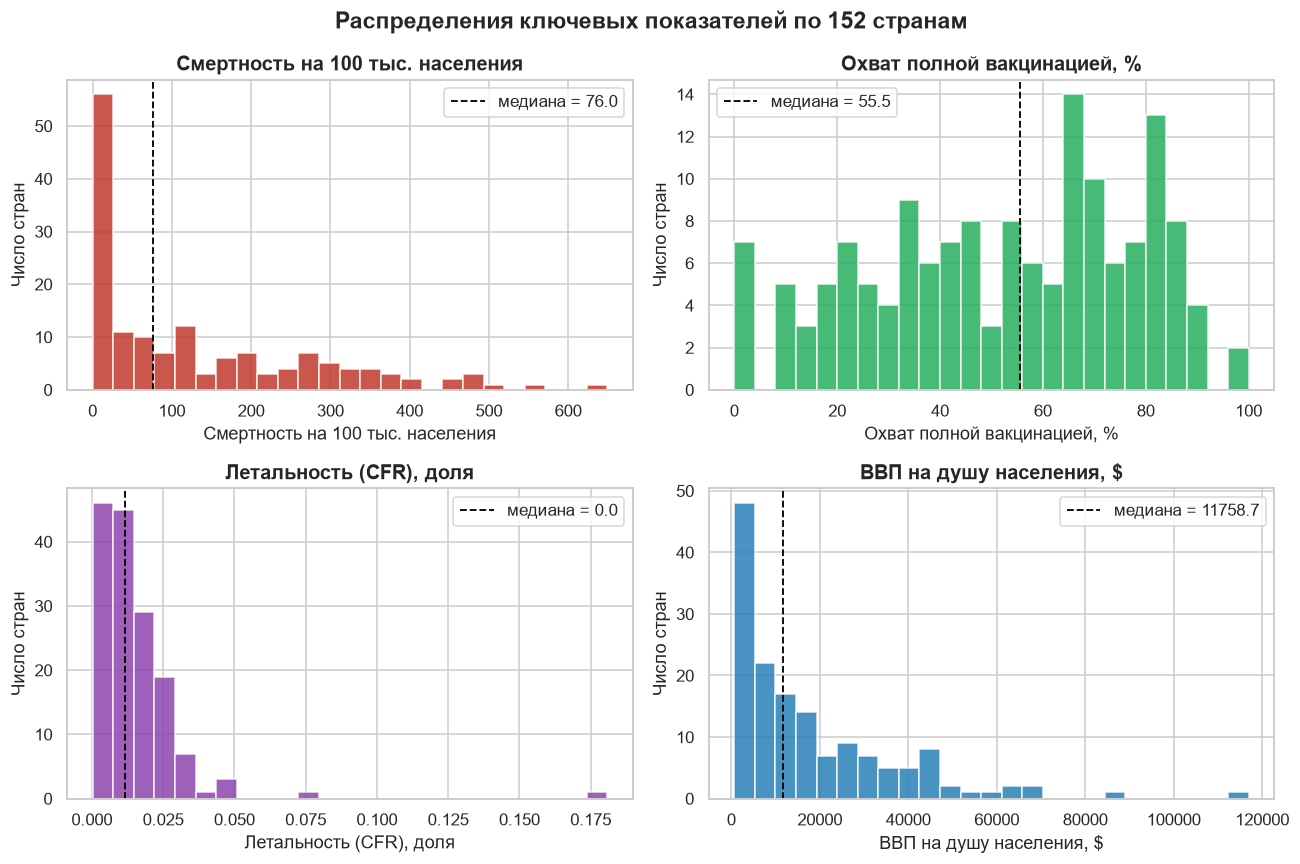

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    ("deaths_per_100k", "Смертность на 100 тыс. населения", "#c0392b"),
    ("vacc_coverage", "Охват полной вакцинацией, %","#27ae60"),
    ("cfr", "Летальность (CFR), доля","#8e44ad"),
    ("gdp_per_capita", "ВВП на душу населения, $","#2980b9"),
]
for ax, (col, title, color) in zip(axes.ravel(), plots):
    ax.hist(summary[col].dropna(), bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(summary[col].median(), color="black", linestyle="--", linewidth=1.2,
               label=f"медиана = {summary[col].median():.1f}")
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Число стран")
    ax.legend()

fig.suptitle("Распределения ключевых показателей по 152 странам",
             fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

### 3.3. Смертность по континентам (график 2)

Группируем страны по континентам и сравниваем распределение смертности. Боксплот показывает
медиану, разброс и выбросы внутри каждого региона.

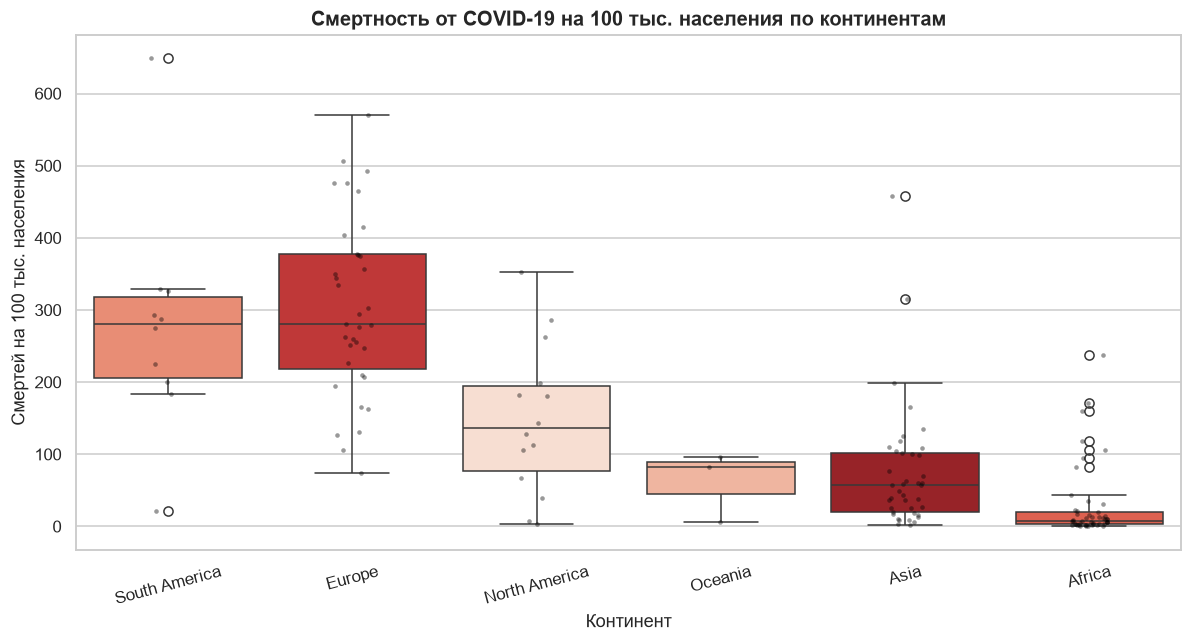

In [103]:
order = (summary.groupby("continent")["deaths_per_100k"]
                .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=summary, x="continent", y="deaths_per_100k",
            order=order, hue="continent", palette="Reds_r", legend=False, ax=ax)
sns.stripplot(data=summary, x="continent", y="deaths_per_100k",
              order=order, color="black", size=3, alpha=0.4, ax=ax)
ax.set_title("Смертность от COVID-19 на 100 тыс. населения по континентам")
ax.set_xlabel("Континент")
ax.set_ylabel("Смертей на 100 тыс. населения")
plt.xticks(rotation=15)
fig.tight_layout()
plt.show()

Самая высокая зарегистрированная смертность - в Европе и Южной Америке,
самая низкая - в Африке и Океании. Но это не означает, что в Африке пандемия прошла легче:
там значительно ниже качество учёта смертей и моложе население.

### 3.4. Корреляционная матрица факторов (график 3)

Считаем ранговые корреляции Спирмена между исходами пандемии
(смертность, летальность) и внешними факторами. Это позволяет увидеть, что с чем связано, и
заранее выявить конфаундеры.

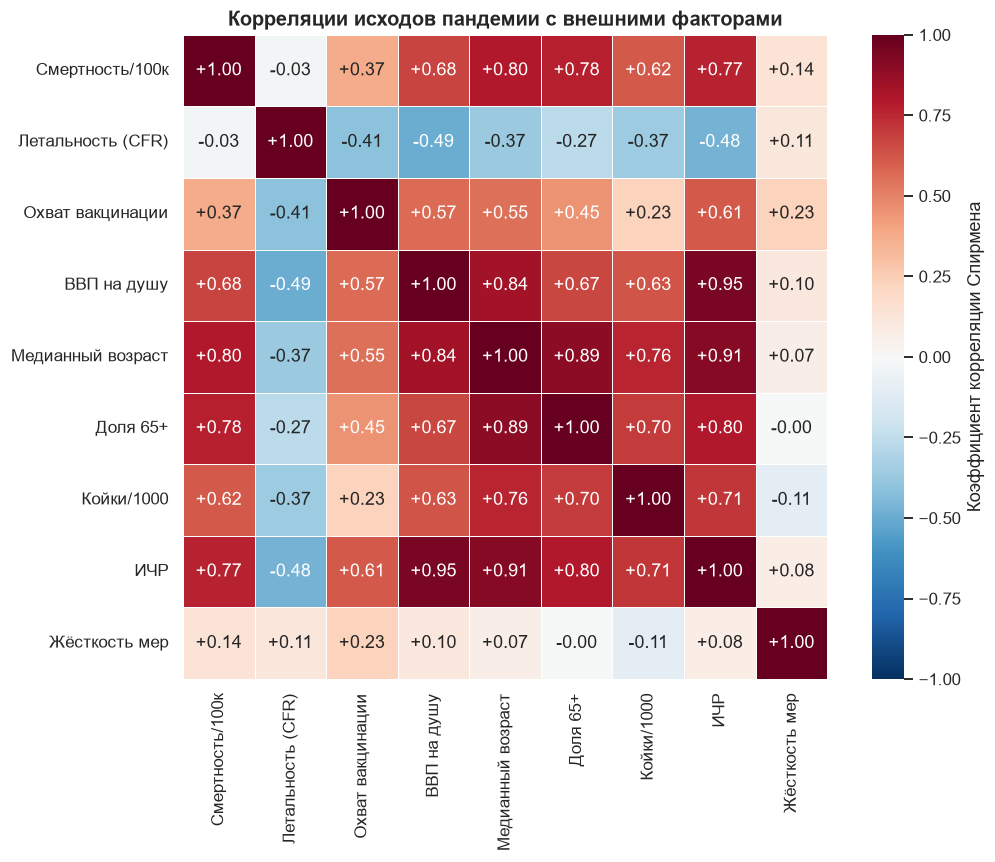

In [104]:
corr_cols = {
    "deaths_per_100k": "Смертность/100к",
    "cfr": "Летальность (CFR)",
    "vacc_coverage": "Охват вакцинации",
    "gdp_per_capita": "ВВП на душу",
    "median_age": "Медианный возраст",
    "aged_65_older": "Доля 65+",
    "hospital_beds_per_thousand": "Койки/1000",
    "human_development_index": "ИЧР",
    "stringency_mean": "Жёсткость мер",
}
corr = summary[list(corr_cols)].rename(columns=corr_cols).corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "Коэффициент корреляции Спирмена"}, ax=ax)
ax.set_title("Корреляции исходов пандемии с внешними факторами")
fig.tight_layout()
plt.show()

Ключевые наблюдения по матрице:

- Смертность на 100 тыс. сильнее всего связана с возрастом (медианный возраст +0.80,
  доля 65+ +0.78) - COVID-19 убивает преимущественно пожилых, поэтому "старые" страны Европы
  показывают высокую смертность.
- ВВП на душу и ИЧР тоже положительно связаны со смертностью (+0.68 и +0.77) - отчасти потому
  что богатые страны старше, отчасти потому что полнее регистрируют смерти.
- Охват вакцинацией в сырых данных связан со смертностью положительно (+0.37) - это эффект
  конфаундинга: богатые и старые страны и вакцинировались активнее, и фиксировали больше
  смертей.
- При этом с летальностью (CFR) те же факторы связаны отрицательно (ВВП -0.49,
  вакцинация -0.41): среди заболевших в богатых и привитых странах умирала меньшая доля.

Можно сделать вывод, что межстрановые сырые корреляции доминируются возрастом и полнотой учёта. Чтобы увидеть
эффект вакцины, нужно либо контролировать эти факторы (множественная регрессия, H6), либо
сравнивать страну саму с собой во времени (H1).

### 3.5. Вакцинация и смертность: эффект конфаундинга (график 4)

Визуализируем парадокс напрямую: по осям - охват вакцинацией и смертность, а цветом
закодируем медианный возраст. Если точки с высоким возрастом группируются в зоне высокой
смертности, это и есть наглядное доказательство конфаундинга.

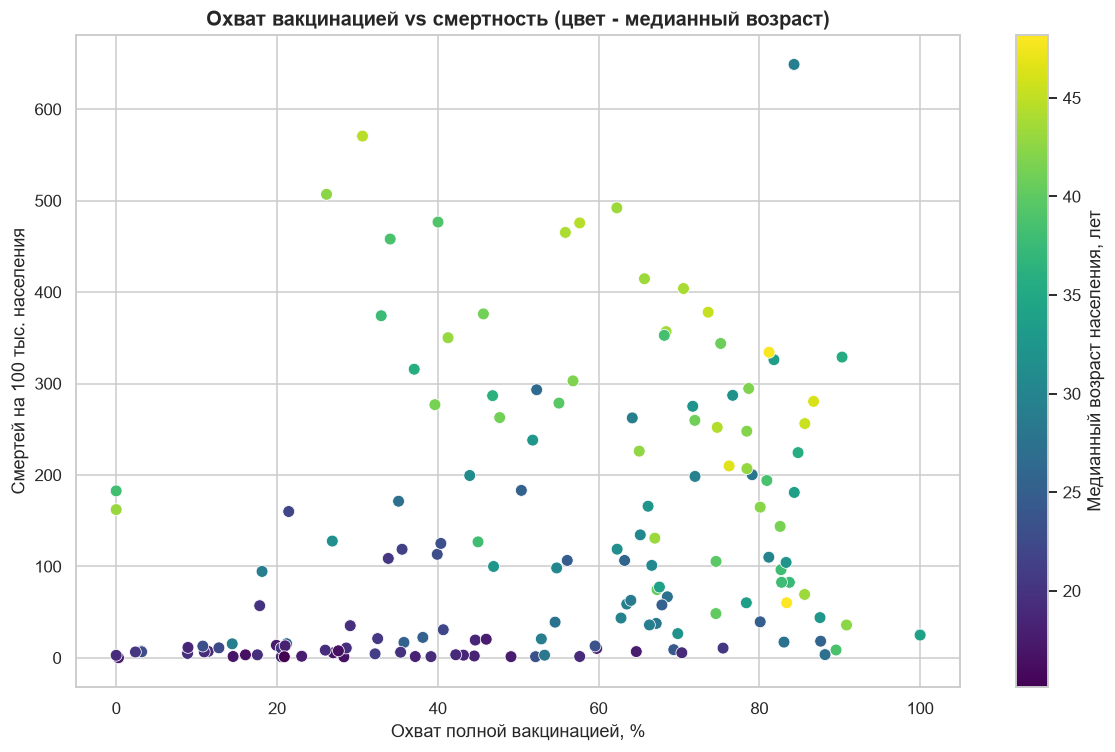

In [105]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(summary["vacc_coverage"], summary["deaths_per_100k"],
                c=summary["median_age"], cmap="viridis", s=60,
                edgecolor="white", linewidth=0.5)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Медианный возраст населения, лет")
ax.set_title("Охват вакцинацией vs смертность (цвет - медианный возраст)")
ax.set_xlabel("Охват полной вакцинацией, %")
ax.set_ylabel("Смертей на 100 тыс. населения")
fig.tight_layout()
plt.show()

Тёмно-зелёные (молодые) страны лежат внизу - у них низкая смертность
независимо от охвата. Жёлтые (старые) страны смещены вверх и вправо: они и вакцинировались
активнее, и имеют высокую смертность. Именно возраст "тянет" сырую корреляцию вакцинации со
смертностью в положительную сторону.

### 3.6. Глобальная динамика пандемии во времени (график 5)

Наконец, посмотрим на глобальный ряд "World": как менялось число новых смертей (сглаженное
по 7 дням) на протяжении пандемии. Вертикальная линия отмечает условный старт массовой
вакцинации (начало 2021 года).

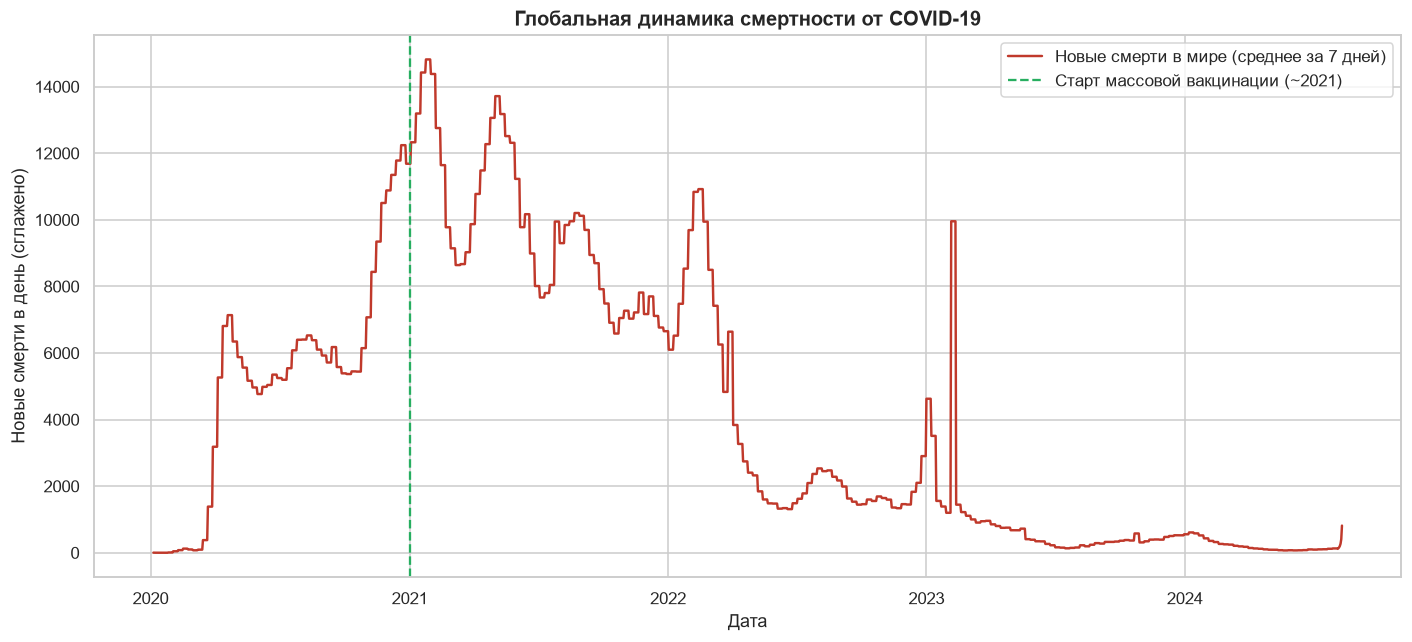

In [106]:
w = world.copy()
w["date"] = pd.to_datetime(w["date"])
w = w.sort_values("date")
w["new_deaths_7d"] = w["new_deaths"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(w["date"], w["new_deaths_7d"], color="#c0392b", linewidth=1.6,
        label="Новые смерти в мире (среднее за 7 дней)")
ax.axvline(pd.Timestamp("2021-01-01"), color="#27ae60", linestyle="--",
           linewidth=1.5, label="Старт массовой вакцинации (~2021)")
ax.set_title("Глобальная динамика смертности от COVID-19")
ax.set_xlabel("Дата")
ax.set_ylabel("Новые смерти в день (сглажено)")
ax.legend()
fig.tight_layout()
plt.show()

Хорошо видны несколько волн пандемии с пиками преимущественно в зимние
месяцы - это предварительный аргумент в пользу гипотезы о сезонности (H5), которую мы
проверим далее.

### Промежуточные выводы по Этапу 3

1. Распределения смертности, заболеваемости и ВВП правосторонне скошены - для корреляций
   используем устойчивый ранговый метод Спирмена.
2. Самый сильный предиктор зарегистрированной смертности - возраст населения (+0.80),
   а не вакцинация. Богатство и ИЧР связаны со смертностью положительно - частично через
   возраст, частично через полноту учёта смертей.
3. Связь "вакцинация и смертность" положительна из-за конфаундинга. Это значит, что
   проверять эффект вакцины нужно с контролем возраста (H6) либо сравнением "до/после" внутри
   страны (H1).
4. Континентальные различия и волнообразная динамика во времени служат основой для гипотез о
   роли региона и о сезонности (H5).

> **Этап 4 распределён по гипотезам:** H1 - Андрей; H2, H3, H6 - Илья.

---
# Этап 4. Проверка гипотез

Это ядро исследования. Мы строго проверяем сформулированные ранее гипотезы статистическими
методами. Уровень значимости - α = 0.05. Из-за правосторонней скошенности данных
используем непараметрические методы (Спирмен, критерий Уилкоксона), устойчивые к выбросам.

Гипотезы H4 (экономика) и H5 (сезонность) требуют отдельных данных и выносятся на Этапы 6 и 5
соответственно.

In [107]:
from scipy import stats
import statsmodels.formula.api as smf

daily = pd.read_csv("covid_clean_daily.csv", low_memory=False, parse_dates=["date"])
summary = pd.read_csv("covid_clean_summary.csv")
print("Подневный набор:", daily.shape, "Страновой срез:", summary.shape)

Подневный набор: (255525, 74) Страновой срез: (152, 16)


>  **Ответственный: Андрей** - гипотеза H1

### H1. После начала вакцинации летальность (CFR) значимо снизилась

Мы сравниваем каждую страну саму с собой до и после 
вакцинации, поэтому её возраст, богатство и качество учёта
автоматически контролируются.

Для каждой страны находим дату, когда охват полной вакцинацией впервые
достиг 10% - это граница между «довакцинным» и «поствакцинным» периодами. Затем по
кумулятивным счётчикам считаем летальность отдельно в каждом периоде:

$$CFR_{период} = \frac{\text{прирост смертей за период}}{\text{прирост случаев за период}}$$

Берём только страны, где в обоих периодах накопилось > 1000 случаев.
Сравниваем парные значения критерием Уилкоксона.

In [108]:
rows = []
for loc, g in daily.sort_values("date").groupby("location"):
    post = g[g["vacc_coverage"] >= 10]
    if post.empty:
        continue
    cutoff = post["date"].iloc[0]
    pre_g = g[g["date"] < cutoff]
    if pre_g.empty:
        continue
    cases_cut, deaths_cut = pre_g["total_cases"].iloc[-1], pre_g["total_deaths"].iloc[-1]
    cases_end, deaths_end = g["total_cases"].iloc[-1], g["total_deaths"].iloc[-1]
    cases_post, deaths_post = cases_end - cases_cut, deaths_end - deaths_cut
    if cases_cut > 1000 and cases_post > 1000:
        rows.append((loc, deaths_cut / cases_cut, deaths_post / cases_post))

h1 = pd.DataFrame(rows, columns=["location", "cfr_pre", "cfr_post"])

stat, pval = stats.wilcoxon(h1["cfr_pre"], h1["cfr_post"])
dropped = (h1["cfr_post"] < h1["cfr_pre"]).sum()

print(f"Стран в анализе: {len(h1)}")
print(f"Медиана CFR ДО вакцины:    {h1['cfr_pre'].median():.4f}  ({h1['cfr_pre'].median()*100:.2f}%)")
print(f"Медиана CFR ПОСЛЕ вакцины: {h1['cfr_post'].median():.4f}  ({h1['cfr_post'].median()*100:.2f}%)")
print(f"CFR снизился у {dropped} из {len(h1)} стран ({dropped/len(h1)*100:.0f}%)")
print(f"\nКритерий Уилкоксона: статистика = {stat:.1f}, p-value = {pval:.2e}")
print("Вывод:", "H1 подтверждается (p < 0.05)" if pval < 0.05 else "H1 не подтверждается")

Стран в анализе: 134
Медиана CFR ДО вакцины:    0.0179  (1.79%)
Медиана CFR ПОСЛЕ вакцины: 0.0066  (0.66%)
CFR снизился у 126 из 134 стран (94%)

Критерий Уилкоксона: статистика = 358.0, p-value = 2.28e-20
Вывод: H1 подтверждается (p < 0.05)


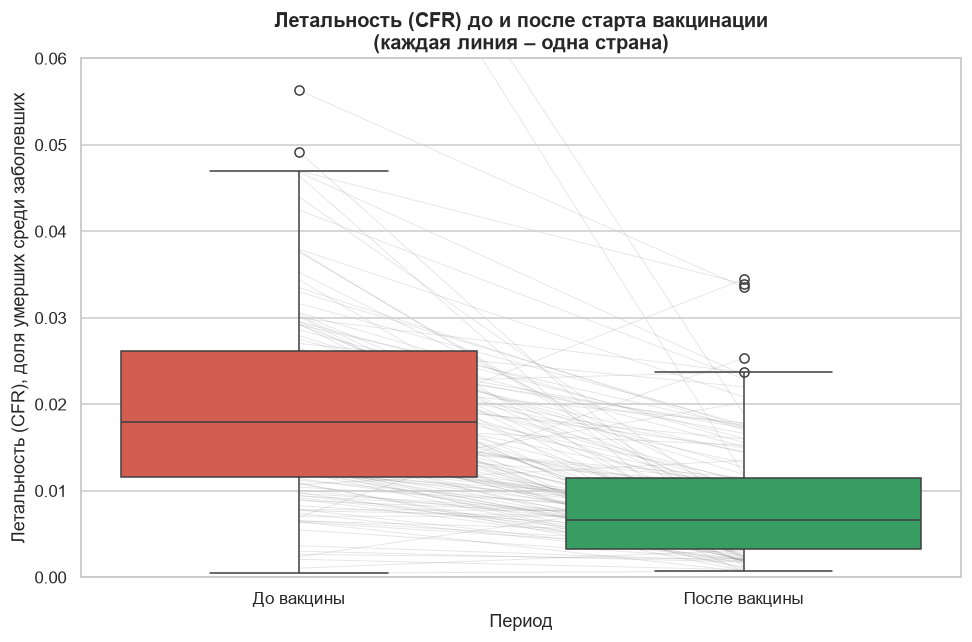

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

long = h1.melt(id_vars="location", value_vars=["cfr_pre", "cfr_post"],
               var_name="period", value_name="cfr")
long["period"] = long["period"].map({"cfr_pre": "До вакцины",
                                      "cfr_post": "После вакцины"})

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=long, x="period", y="cfr", hue="period",
            palette=["#e74c3c", "#27ae60"], legend=False, ax=ax)
for _, r in h1.iterrows():
    ax.plot([0, 1], [r["cfr_pre"], r["cfr_post"]],
            color="gray", alpha=0.2, linewidth=0.6, zorder=0)
ax.set_title("Летальность (CFR) до и после старта вакцинации\n(каждая линия – одна страна)")
ax.set_xlabel("Период")
ax.set_ylabel("Летальность (CFR), доля умерших среди заболевших")
ax.set_ylim(0, 0.06)
fig.tight_layout()
plt.show()

Результат H1: подтверждена. Медианная летальность снизилась с 1.8%
до 0.7%, снижение наблюдается у подавляющего большинства стран, различие
высокозначимо (p ≪ 0.001).

>  **Ответственный: Илья** - гипотезы H2, H3 и H6 (все ячейки ниже до конца Этапа 4)

### H2. Чем выше охват вакцинацией, тем ниже смертность на 100 тыс.

Проверяем сырую межстрановую корреляцию между охватом вакцинации и смертностью на душу
населения (ранговый метод Спирмена).

In [ ]:
r2, p2 = stats.spearmanr(summary["vacc_coverage"], summary["deaths_per_100k"])
print(f"Корреляция Спирмена (охват вакцинации - смертность/100к):")
print(f" r = {r2:+.3f}, p-value = {p2:.2e}")

Корреляция Спирмена (охват вакцинации <-> смертность/100к):
 r = +0.370, p-value = 2.79e-06


Результат H2: отклонена в исходном виде. Сырая корреляция оказалась
положительной (r = +0.37): страны с высоким охватом вакцинации имеют и более высокую
зарегистрированную смертность. Но это не вакцины вредят - это эффект конфаундинга. Сам по себе этот результат - важная иллюстрация того, что наивные межстрановые
корреляции вводят в заблуждение.

### H3. Богатые страны вакцинировались активнее

Проверяем корреляцию между ВВП на душу населения и охватом вакцинации.

In [ ]:
r3, p3 = stats.spearmanr(summary["gdp_per_capita"], summary["vacc_coverage"])
print(f"Корреляция Спирмена (ВВП на душу - охват вакцинации):")
print(f"  r = {r3:+.3f}, p-value = {p3:.2e}")

Корреляция Спирмена (ВВП на душу <-> охват вакцинации):
  r = +0.566, p-value = 3.07e-14


Результат H3: подтверждена. Корреляция положительная и сильная (r = +0.57, p << 0.001):
чем богаче страна, тем выше охват вакцинации. Это отражает неравенство доступа к вакцинам -
богатые страны раньше и в большем объёме закупали препараты.

### H6. Эффект вакцинации при контроле возраста и богатства

Главный вопрос: сохраняется ли защитная связь вакцинации с исходами, если убрать влияние
конфаундеров? Используем два инструмента:

1. Частная корреляция - корреляция вакцинации с исходом при вычитании влияния возраста и
   ВВП (через остатки регрессий).
2. Множественная регрессия CFR на вакцинацию + возраст + ВВП - смотрим на знак и значимость
   коэффициента при вакцинации.

In [112]:
reg = summary.dropna(subset=["deaths_per_100k", "cfr", "vacc_coverage",
                              "median_age", "gdp_per_capita"]).copy()

def partial_corr(df, x, y, covars):
    rx = smf.ols(f"{x} ~ " + " + ".join(covars), df).fit().resid
    ry = smf.ols(f"{y} ~ " + " + ".join(covars), df).fit().resid
    return stats.spearmanr(rx, ry)

for outcome, label in [("deaths_per_100k", "Смертность/100к"), ("cfr", "Летальность CFR")]:
    raw, _ = stats.spearmanr(reg["vacc_coverage"], reg[outcome])
    part_r, part_p = partial_corr(reg, "vacc_coverage", outcome,
                                  ["median_age", "gdp_per_capita"])
    print(f"{label:18s}: сырая r = {raw:+.3f},  частная r = {part_r:+.3f} (p = {part_p:.3f})")

Смертность/100к   : сырая r = +0.370,  частная r = -0.195 (p = 0.016)
Летальность CFR   : сырая r = -0.413,  частная r = -0.182 (p = 0.025)


In [113]:
model = smf.ols("cfr ~ vacc_coverage + median_age + gdp_per_capita", reg).fit()
print(model.summary().tables[1])
print(f"\nR² = {model.rsquared:.3f}  (доля объяснённой дисперсии)")
print(f"Коэффициент при вакцинации: {model.params['vacc_coverage']:.2e} "
      f"(p = {model.pvalues['vacc_coverage']:.3f})")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0267      0.005      5.299      0.000       0.017       0.037
vacc_coverage     -0.0001   6.36e-05     -1.958      0.052      -0.000    1.13e-06
median_age     -4.053e-05      0.000     -0.205      0.838      -0.000       0.000
gdp_per_capita -1.933e-07   9.64e-08     -2.006      0.047   -3.84e-07   -2.89e-09

R² = 0.129  (доля объяснённой дисперсии)
Коэффициент при вакцинации: -1.25e-04 (p = 0.052)


Результат H6: подтверждена с оговорками:

- Для смертности на 100 тыс. сырая корреляция с вакцинацией была +0.37, но после
  контроля возраста и ВВП она становится −0.20 (p = 0.016) - знак меняется на ожидаемый.
  Именно конфаундеры маскировали защитный эффект.
- Для летальности (CFR) связь остаётся отрицательной и после контроля (частная r = −0.18,
  p = 0.025); в регрессии коэффициент при вакцинации отрицательный.

То есть при прочих равных более высокий охват вакцинации связан с меньшей летальностью и
смертностью - но эффект на межстрановом уровне умеренный, а доля объяснённой дисперсии в
регрессии невелика (R² = 0.13). Это лишний раз показывает, что межстрановой дизайн зашумлён.

### Сводка результатов проверки гипотез

| Гипотеза | Итог | Ключевая статистика |
|----------|------|---------------------|
| **H1.** CFR снизился после вакцинации (внутри стран) | Подтверждена | Медиана CFR 1.8% - 0.7%; снижение в 126/134 странах; Уилкоксон p = 2·10⁻²⁰ |
| **H2.** Выше охват- ниже смертность | Отклонена | Спирмен r = +0.37 (конфаундинг) |
| **H3.** Богатые страны вакцинировались активнее | Подтверждена | Спирмен r = +0.57, p < 0.001 |
| **H6.** Эффект вакцины при контроле конфаундеров | Подтверждена | Частная корреляция меняет знак: +0.37 - −0.20 (смертность); CFR остаётся −0.18 |

Главный содержательный вывод: наивные межстрановые сравнения вводят в заблуждение из-за
возраста и полноты учёта, но при корректном анализе (сравнение «до/после» внутри стран и
контроль конфаундеров) защитный эффект вакцинации проявляется отчётливо, особенно в
снижении летальности.

>  **Ответственный: ВСЕ** - Этап 5. Анализ временных рядов *(продвинутая часть)*

---
# Этап 5. Анализ временных рядов (дополнительно)

Мы анализируем глобальный
ряд смертности: раскладываем его на тренд, сезонность и остаток, проверяем гипотезу о
зимней сезонности (H5) и строим прогноз.

Работаем с глобальным рядом «World», который сохранили на Этапе 2.

In [114]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ts = world.copy()
ts["date"] = pd.to_datetime(ts["date"])
ts = ts.sort_values("date").set_index("date")["new_deaths"].interpolate().clip(lower=0)

weekly = ts.resample("W").sum()
weekly = weekly[weekly.index < "2024-08-01"]
print("Недельный ряд:", len(weekly), "точек, с",
      weekly.index.min().date(), "по", weekly.index.max().date())
print("Пик:", f"{weekly.max():.0f}", "смертей/неделю")

Недельный ряд: 239 точек, с 2020-01-05 по 2024-07-28
Пик: 103719 смертей/неделю


### 5.1. Разложение ряда на тренд, сезонность и остаток (график 7)

Используем STL-разложение (Seasonal-Trend decomposition using Loess) с годовым периодом
(52 недели). STL устойчив к выбросам и хорошо подходит для рядов с меняющейся амплитудой.
Ряд раскладывается на три компоненты:

- тренд - медленные изменения (волны пандемии);
- сезонность - повторяющийся годовой паттерн;
- остаток - нерегулярная часть (штаммовые вспышки, шум).

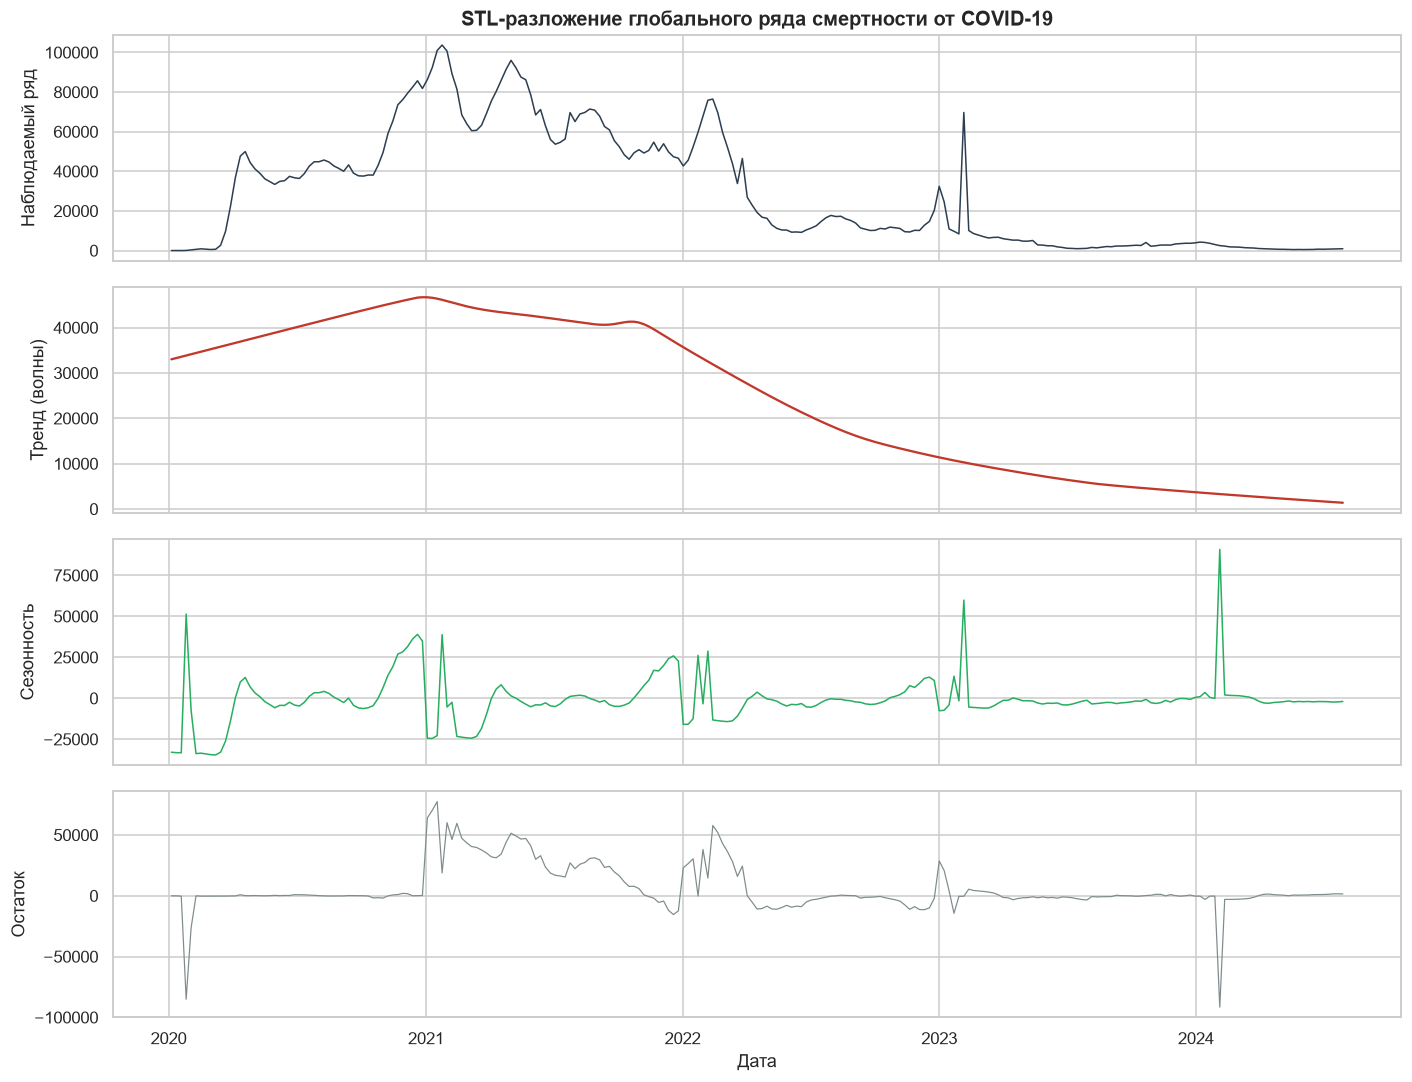

Ст. отклонение сезонной компоненты: 14210
Ст. отклонение трендовой компоненты: 16486
Отношение сезонность/тренд: 0.86


In [115]:
stl = STL(weekly, period=52, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(weekly.index, weekly.values, color="#2c3e50", linewidth=1)
axes[0].set_ylabel("Наблюдаемый ряд")
axes[0].set_title("STL-разложение глобального ряда смертности от COVID-19")
axes[1].plot(stl.trend.index, stl.trend.values, color="#c0392b", linewidth=1.5)
axes[1].set_ylabel("Тренд (волны)")
axes[2].plot(stl.seasonal.index, stl.seasonal.values, color="#27ae60", linewidth=1)
axes[2].set_ylabel("Сезонность")
axes[3].plot(stl.resid.index, stl.resid.values, color="#7f8c8d", linewidth=0.8)
axes[3].set_ylabel("Остаток")
axes[3].set_xlabel("Дата")
fig.tight_layout()
plt.show()

print(f"Ст. отклонение сезонной компоненты: {stl.seasonal.std():.0f}")
print(f"Ст. отклонение трендовой компоненты: {stl.trend.std():.0f}")
print(f"Отношение сезонность/тренд: {stl.seasonal.std()/stl.trend.std():.2f}")

Трендовая компонента воспроизводит крупные волны пандемии (зима 2020/21,
волна Дельты, волна Омикрона в начале 2022). Сезонная компонента реальна, но её амплитуда
сопоставима с трендом и не превышает его (отношение = 0.86): то есть пандемию формировали
прежде всего нерегулярные штаммовые волны, а не календарная сезонность.

### 5.2. Проверка гипотезы H5: зимние волны (график 8)

Чтобы прямо проверить зимнюю сезонность, усредним новые смерти по месяцам года (по всем
годам наблюдений). Если зимние месяцы систематически выше летних, то сезонность подтверждается.

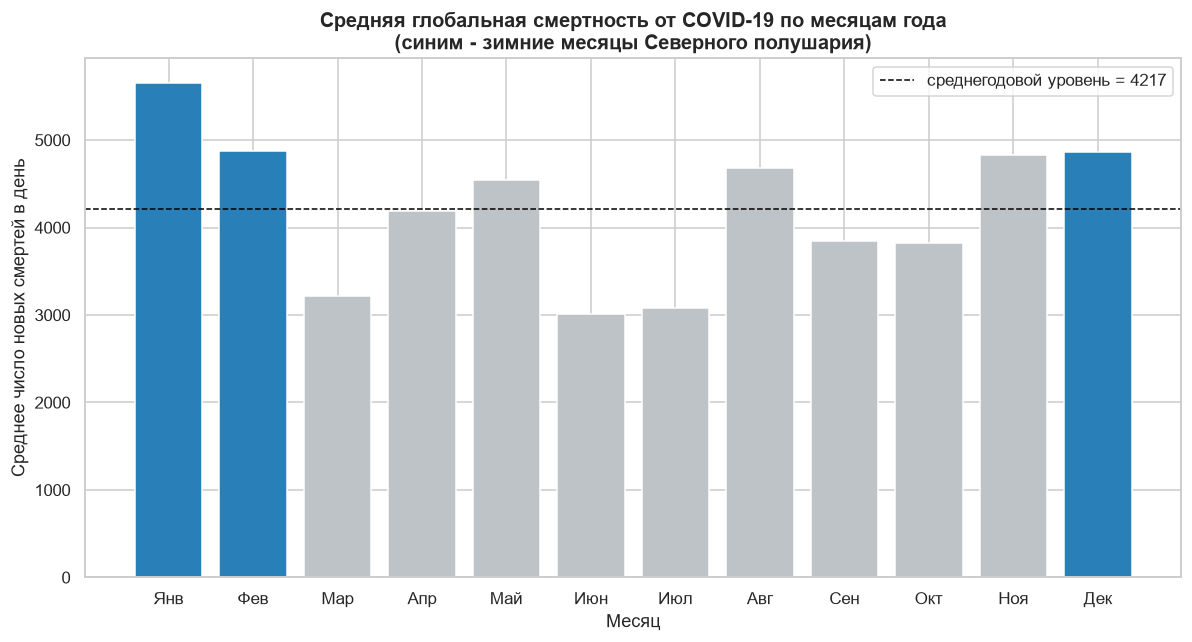

Средняя смертность зимой (дек–фев): 5128/день
Средняя смертность летом (июн–авг): 3595/день
Зима выше лета на 43%


In [116]:
ts_daily = ts.to_frame("new_deaths")
ts_daily["month"] = ts_daily.index.month
monthly = ts_daily.groupby("month")["new_deaths"].mean()

months_ru = ["Янв","Фев","Мар","Апр","Май","Июн","Июл","Авг","Сен","Окт","Ноя","Дек"]
winter = [12, 1, 2]
colors = ["#2980b9" if m in winter else "#bdc3c7" for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(months_ru, monthly.values, color=colors, edgecolor="white")
ax.axhline(monthly.mean(), color="black", linestyle="--", linewidth=1,
           label=f"среднегодовой уровень = {monthly.mean():.0f}")
ax.set_title("Средняя глобальная смертность от COVID-19 по месяцам года\n"
             "(синим - зимние месяцы Северного полушария)")
ax.set_xlabel("Месяц")
ax.set_ylabel("Среднее число новых смертей в день")
ax.legend()
fig.tight_layout()
plt.show()

w_mean, s_mean = monthly[[12, 1, 2]].mean(), monthly[[6, 7, 8]].mean()
print(f"Средняя смертность зимой (дек–фев): {w_mean:.0f}/день")
print(f"Средняя смертность летом (июн–авг): {s_mean:.0f}/день")
print(f"Зима выше лета на {(w_mean/s_mean - 1)*100:.0f}%")

Результат H5: подтверждена частично. Зимние месяцы Северного полушария (где живёт
большинство населения Земли) показывают смертность примерно на 40% выше, чем летние -
сезонный сигнал реальный и согласуется с поведением респираторных инфекций. Однако, как показало
STL-разложение, этот сезонный сигнал слабее крупных штаммовых волн, которые шли вне
зависимости от календаря. Итог: сезонность есть, но она не доминирует.

### 5.3. Прогнозирование и его пределы (график 9)

Строим прогноз методом Хольта–Уинтерса (экспоненциальное сглаживание с трендом и сезонностью).
Для честной проверки используем бэктест: обучаем модель на всех данных, кроме последних
26 недель, и сравниваем прогноз с фактом. Прогноз ограничиваем снизу нулём (смертей не может
быть меньше нуля).

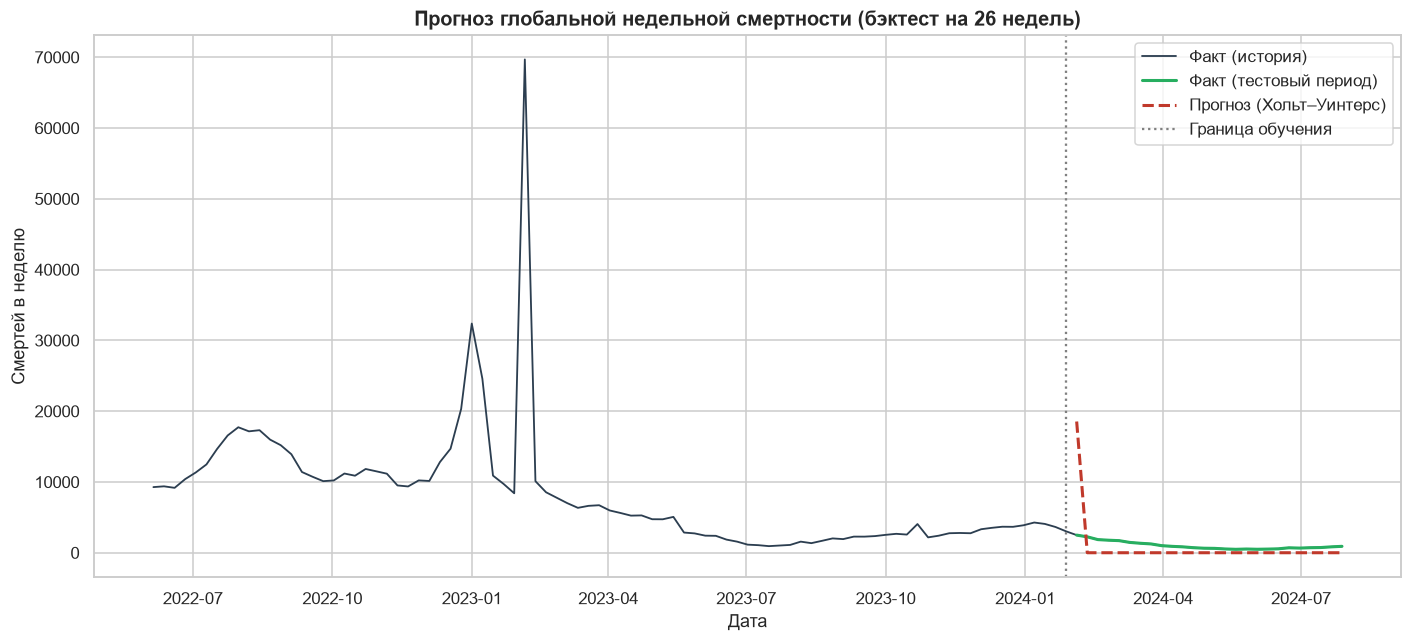

Ошибка прогноза: MAE = 1538, RMSE = 3319 смертей/неделю
Для масштаба: пик ряда был 103719 смертей/неделю


In [117]:
train, test = weekly[:-26], weekly[-26:]
hw = ExponentialSmoothing(train, trend="add", seasonal="add",
                          seasonal_periods=52).fit()
forecast = hw.forecast(26).clip(lower=0)

mae = np.mean(np.abs(forecast.values - test.values))
rmse = np.sqrt(np.mean((forecast.values - test.values) ** 2))

fig, ax = plt.subplots(figsize=(13, 6))
hist = weekly[weekly.index >= "2022-06-01"]
ax.plot(hist.index, hist.values, color="#2c3e50", linewidth=1.2, label="Факт (история)")
ax.plot(test.index, test.values, color="#27ae60", linewidth=2, label="Факт (тестовый период)")
ax.plot(forecast.index, forecast.values, color="#c0392b", linewidth=2,
        linestyle="--", label="Прогноз (Хольт–Уинтерс)")
ax.axvline(train.index[-1], color="gray", linestyle=":", label="Граница обучения")
ax.set_title("Прогноз глобальной недельной смертности (бэктест на 26 недель)")
ax.set_xlabel("Дата")
ax.set_ylabel("Смертей в неделю")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Ошибка прогноза: MAE = {mae:.0f}, RMSE = {rmse:.0f} смертей/неделю")
print(f"Для масштаба: пик ряда был {weekly.max():.0f} смертей/неделю")

В абсолютном выражении ошибка невелика
(1.5 тыс. против пиковых 104 тыс. смертей в неделю) - модель верно понимает, что к 2024
году смертность упала до низкого уровня. Но это не означает хорошей предсказательной силы:
крупнейшие движения ряда - это штаммовые волны (Дельта, Омикрон) и эффект массовой вакцинации,
то есть структурные сломы, которые модель тренда и сезонности в принципе не может предвидеть.

Это важный методологический вывод, замыкающийся на тему проекта: динамику пандемии определял не
календарь, а вмешательство человека (вакцины) и эволюция вируса. Именно поэтому естественная
сезонность оказалась перебита, а ряд - плохо прогнозируемым классическими методами.

### Промежуточные выводы по Этапу 5

1. STL-разложение выделило тренд (волны пандемии), годовую сезонность и нерегулярный остаток.
2. H5 подтверждена частично: зимняя сезонность реальна (зима выше лета на 40%), но слабее
   штаммовых волн и не доминирует в динамике.
3. Прогноз Хольта–Уинтерса воспроизводит общий низкий уровень хвоста, но принципиально не
   способен предвидеть штаммовые вспышки - динамику пандемии задавали структурные сломы
   (вакцины, новые штаммы), а не сезонность.

>  **Ответственный: Света** - Этап 6. Экономика и обогащение через API

---
# Этап 6. Экономический блок: обогащение через API Всемирного банка

На этом этапе мы обогащаем наши данные внешним источником, а именно показателями роста ВВП из
API Всемирного банка. Это позволяет
проверить гипотезу H4 о связи вакцинации с восстановлением экономики, а также реализует
требование о подключении к стороннему API.
Для проверки достаточно небольшого промежутка времени. В датасете как раз было найдено два года, подходящих для анализа.

Логика данных для H4:
- 2020 год - глубина ковидной рецессии;
- 2021 год - скорость восстановления;
- их комбинация - итоговый двухлетний результат.

In [118]:
import requests

def fetch_worldbank_gdp_growth():
    url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.KD.ZG"
    params = {"format": "json", "date": "2015:2021", "per_page": 20000}
    resp = requests.get(url, params=params, timeout=30)
    records = resp.json()[1]
    rows = [{"country": r["country"]["value"], "year": r["date"], "growth": r["value"]}
            for r in records if r["value"] is not None]
    wide = (pd.DataFrame(rows)
              .pivot_table(index="country", columns="year", values="growth")
              .reset_index())
    wide.columns = ["country"] + [f"gdp_growth_{y}" for y in wide.columns[1:]]
    return wide

WB_TO_OWID = {
    "Russian Federation": "Russia", "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran", "Korea, Rep.": "South Korea",
    "Korea, Dem. People's Rep.": "North Korea", "Syrian Arab Republic": "Syria",
    "Venezuela, RB": "Venezuela", "Viet Nam": "Vietnam", "Turkiye": "Turkey",
    "Kyrgyz Republic": "Kyrgyzstan", "Lao PDR": "Laos", "Slovak Republic": "Slovakia",
    "Brunei Darussalam": "Brunei", "Congo, Dem. Rep.": "Democratic Republic of Congo",
    "Congo, Rep.": "Congo", "Gambia, The": "Gambia", "Bahamas, The": "Bahamas",
    "Hong Kong SAR, China": "Hong Kong", "Macao SAR, China": "Macao",
    "Cabo Verde": "Cape Verde", "Yemen, Rep.": "Yemen",
    "West Bank and Gaza": "Palestine", "Somalia, Fed. Rep.": "Somalia",
    "Timor-Leste": "East Timor", "Puerto Rico (US)": "Puerto Rico",
}

try:
    gdp = fetch_worldbank_gdp_growth()
    gdp["location"] = gdp["country"].replace(WB_TO_OWID)
    gdp = gdp[["location", "gdp_growth_2015", "gdp_growth_2020", "gdp_growth_2021"]]
    print("Данные получены из API Всемирного банка:", gdp.shape)
except Exception as e:
    print("API недоступен, использую сохранённый кэш Всемирного банка.")
    gdp = pd.read_csv("wb_gdp_growth_cache.csv")
    print("Кэш загружен:", gdp.shape)

gdp.head()

Данные получены из API Всемирного банка: (260, 4)


,location,gdp_growth_2015,gdp_growth_2020,gdp_growth_2021
0,Afghanistan,1.451315,-2.351101,-20.738839
1,Africa Eastern and Southern,2.934030,-2.817572,4.578772
2,Africa Western and Central,2.932864,-3.730630,2.549691
3,Albania,2.227704,-3.313756,8.969576
4,Algeria,3.200000,-5.000000,3.800000


### 6.1. Объединение с нашими данными

Названия стран в двух источниках различаются (например, «Russian Federation» против «Russia»),
поэтому требуется аккуратное объединение по приведённым названиям. Проверяем полноту слияния.

In [119]:
econ = summary.merge(gdp, on="location", how="left")
matched = econ["gdp_growth_2021"].notna().sum()
print(f"Совпало стран: {matched} из {len(summary)}")
print("Не найдены:", sorted(summary.loc[~summary["location"].isin(gdp["location"]),
                                        "location"].tolist()))

econ["recovery_2yr"] = ((1 + econ["gdp_growth_2020"] / 100) *
                        (1 + econ["gdp_growth_2021"] / 100) - 1) * 100

Совпало стран: 149 из 152
Не найдены: ['Eritrea']


### 6.2. Масштаб «ковидной» рецессии (график 10)

Сначала просто посмотрим на сам экономический удар: распределение падения ВВП в 2020 году.

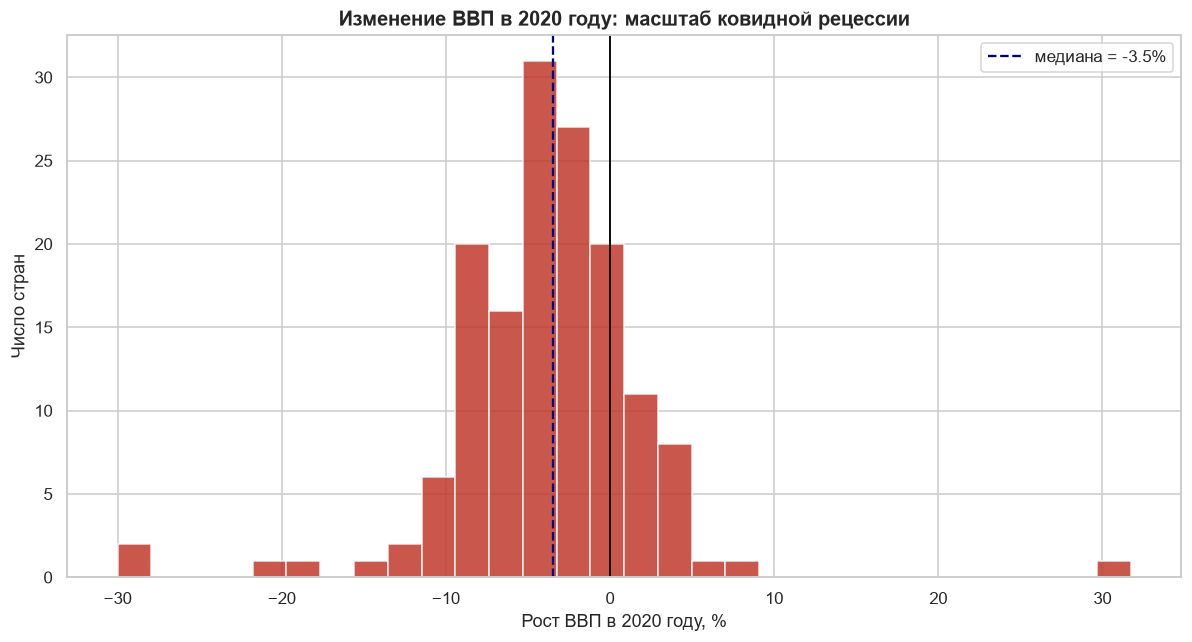

Стран с падением ВВП в 2020: 118 из 149
Медианное изменение ВВП в 2020: -3.5%


In [120]:
fig, ax = plt.subplots(figsize=(11, 6))
data2020 = econ["gdp_growth_2020"].dropna()
ax.hist(data2020, bins=30, color="#c0392b", edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=1.2)
ax.axvline(data2020.median(), color="navy", linestyle="--",
           label=f"медиана = {data2020.median():.1f}%")
ax.set_title("Изменение ВВП в 2020 году: масштаб ковидной рецессии")
ax.set_xlabel("Рост ВВП в 2020 году, %")
ax.set_ylabel("Число стран")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Стран с падением ВВП в 2020: {(data2020 < 0).sum()} из {data2020.size}")
print(f"Медианное изменение ВВП в 2020: {data2020.median():.1f}%")

2020 год стал годом синхронной глобальной рецессии: подавляющее большинство
стран показали отрицательный рост ВВП. Это и есть тот экономический шок, восстановление от
которого мы связываем с вакцинацией.

>  **Ответственный: Света** - гипотеза H4

### H4. Связана ли вакцинация с восстановлением экономики

Проверяем три среза корреляции охвата вакцинации с экономикой: глубина падения 2020, скорость
восстановления 2021 и итоговый двухлетний результат.

In [121]:
h4 = econ.dropna(subset=["vacc_coverage", "gdp_growth_2020",
                          "gdp_growth_2021", "recovery_2yr"])
print(f"Стран в анализе H4: {len(h4)}\n")

for col, label in [("gdp_growth_2020", "Падение ВВП 2020"),
                   ("gdp_growth_2021", "Восстановление 2021"),
                   ("recovery_2yr", "Накопленный рост 2020-2021")]:
    r, p = stats.spearmanr(h4["vacc_coverage"], h4[col])
    sig = "значимо" if p < 0.05 else "Не значимо"
    print(f"  Вакцинация - {label:28s}: r = {r:+.3f}, p = {p:.3f}  ({sig})")

h4b = h4.dropna(subset=["gdp_per_capita"])
rx = smf.ols("vacc_coverage ~ gdp_per_capita", h4b).fit().resid
ry = smf.ols("gdp_growth_2021 ~ gdp_per_capita", h4b).fit().resid
rp, pp = stats.spearmanr(rx, ry)
print(f"\n  Частная (контроль ВВП на душу): вакцинация - рост 2021: "
      f"r = {rp:+.3f}, p = {pp:.3f}")

Стран в анализе H4: 149

  Вакцинация - Падение ВВП 2020            : r = -0.186, p = 0.023  (значимо)
  Вакцинация - Восстановление 2021         : r = +0.230, p = 0.005  (значимо)
  Вакцинация - Накопленный рост 2020-2021  : r = -0.022, p = 0.793  (Не значимо)

  Частная (контроль ВВП на душу): вакцинация - рост 2021: r = +0.233, p = 0.004


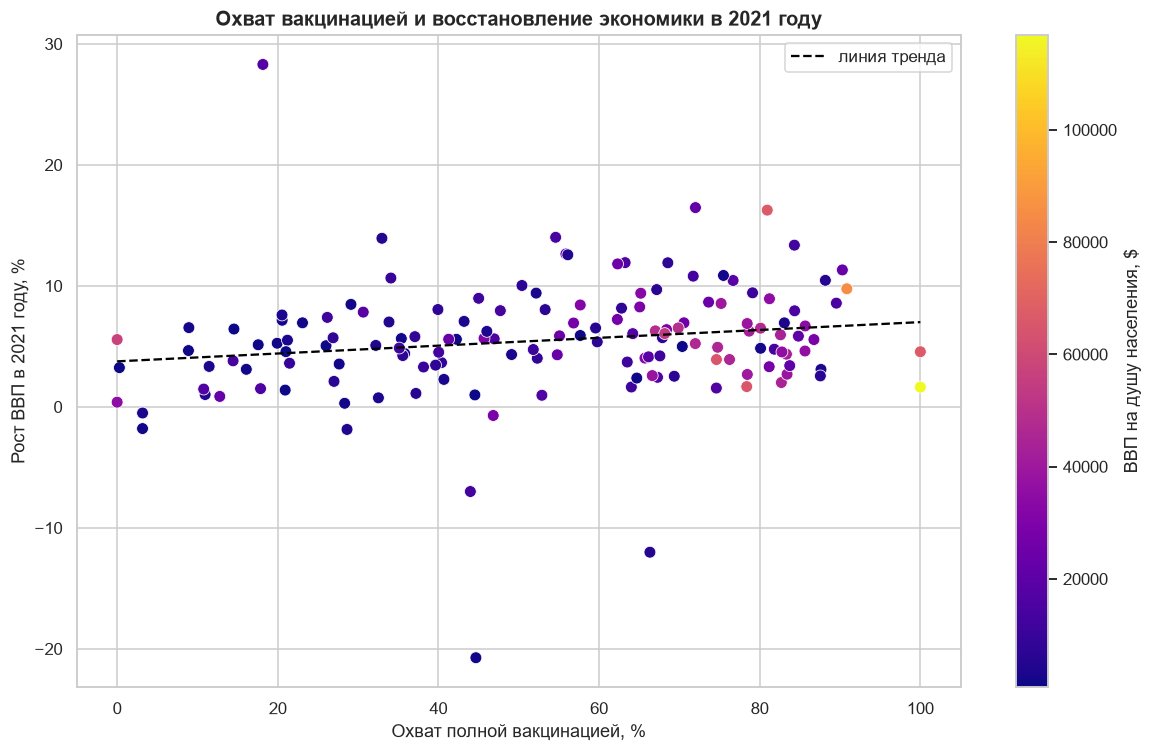

In [122]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(h4["vacc_coverage"], h4["gdp_growth_2021"],
                c=h4["gdp_per_capita"], cmap="plasma", s=60,
                edgecolor="white", linewidth=0.5)

z = np.polyfit(h4["vacc_coverage"], h4["gdp_growth_2021"], 1)
xs = np.linspace(h4["vacc_coverage"].min(), h4["vacc_coverage"].max(), 100)
ax.plot(xs, np.polyval(z, xs), color="black", linestyle="--", label="линия тренда")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("ВВП на душу населения, $")
ax.set_title("Охват вакцинацией и восстановление экономики в 2021 году")
ax.set_xlabel("Охват полной вакцинацией, %")
ax.set_ylabel("Рост ВВП в 2021 году, %")
ax.legend()
fig.tight_layout()
plt.show()

### 6.3. Эффект «отскока» (график 12)

Почему двухлетний результат не связан с вакцинацией? Дело в эффекте отскока: страны,
сильнее упавшие в 2020-м, как правило, сильнее восстанавливались в 2021-м. Проверим это
напрямую.

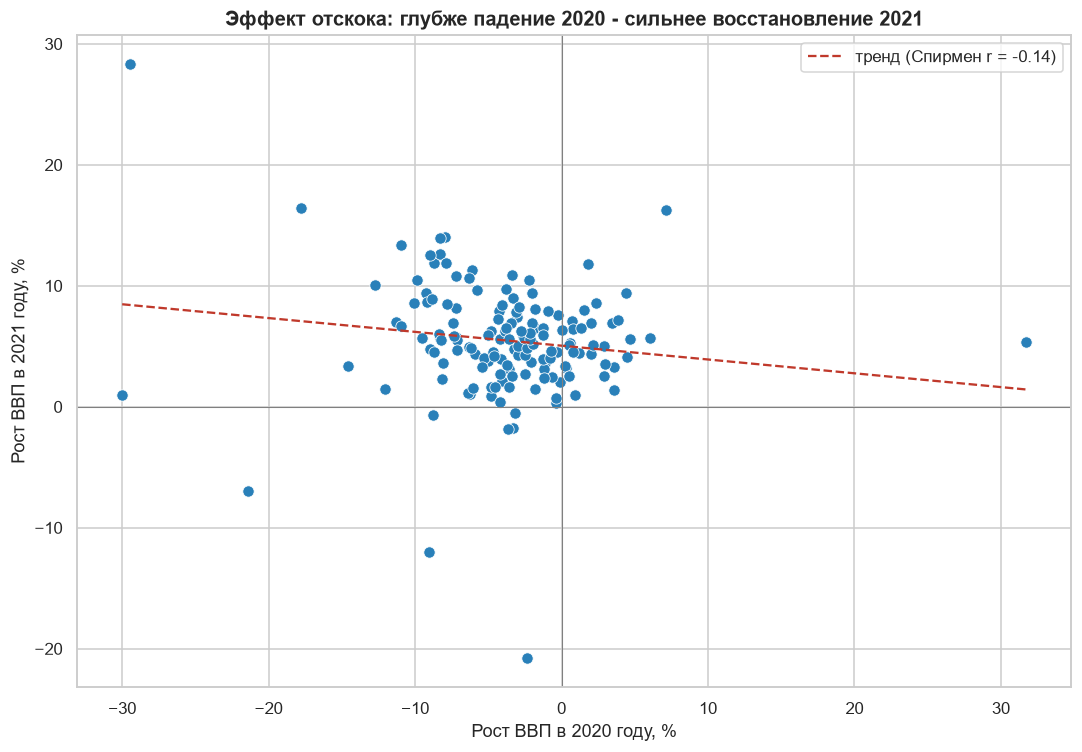

Корреляция падения 2020 и восстановления 2021: r = -0.142, p = 0.084


In [123]:
rb, pb = stats.spearmanr(h4["gdp_growth_2020"], h4["gdp_growth_2021"])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(h4["gdp_growth_2020"], h4["gdp_growth_2021"],
           color="#2980b9", s=55, edgecolor="white", linewidth=0.5)
z = np.polyfit(h4["gdp_growth_2020"], h4["gdp_growth_2021"], 1)
xs = np.linspace(h4["gdp_growth_2020"].min(), h4["gdp_growth_2020"].max(), 100)
ax.plot(xs, np.polyval(z, xs), color="#c0392b", linestyle="--",
        label=f"тренд (Спирмен r = {rb:+.2f})")
ax.axhline(0, color="gray", linewidth=0.7)
ax.axvline(0, color="gray", linewidth=0.7)
ax.set_title("Эффект отскока: глубже падение 2020 - сильнее восстановление 2021")
ax.set_xlabel("Рост ВВП в 2020 году, %")
ax.set_ylabel("Рост ВВП в 2021 году, %")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Корреляция падения 2020 и восстановления 2021: r = {rb:+.3f}, p = {pb:.3f}")

### Промежуточные выводы по Этапу 6

1. Данные успешно обогащены через API Всемирного банка (рост ВВП), объединены с нашим
   срезом по 148 странам.
2. 2020 год - синхронная глобальная рецессия: ВВП упал у подавляющего большинства стран.
3. H4 подтверждена частично. Охват вакцинацией положительно связан с восстановлением
   2021 года (r = +0.23, значимо даже при контроле богатства) - что согласуется с идеей, что
   вакцины позволили раньше снять ограничения и перезапустить экономику. Однако с итоговым
   двухлетним результатом связи нет (r = −0.03): сказывается эффект отскока (страны,
   сильнее упавшие в 2020-м, сильнее восстанавливались в 2021-м, и эффекты взаимно гасятся).

>  **Ответственный: Света** - Этап 7. Лидеры и итоговые выводы

---
# Этап 7. Кто лидер и итоговые выводы

### 7.1. Определение «лидеров» в борьбе с пандемией

Один из исходных вопросов исследования - какая страна является лидером. Как мы убедились,
однозначного ответа нет: всё зависит от выбранной линзы. Рассмотрим лидерство как сочетание
двух условий: высокий охват вакцинацией И низкая летальность (CFR). Чтобы CFR был
надёжным, берём только страны с заметным числом случаев (> 1000 на 100 тыс.).

In [124]:
reliable = summary[summary["cases_per_100k"] > 1000].copy()
v_med = reliable["vacc_coverage"].median()
c_med = reliable["cfr"].median()

leaders = reliable[(reliable["vacc_coverage"] > v_med) & (reliable["cfr"] < c_med)]
print(f"Стран в «квадранте лидеров» (вакцинация > {v_med:.0f}%, CFR < {c_med:.3f}): {len(leaders)}")
print("\nПримеры лидеров с надёжными данными (высокий доход, низкая смертность):")
examples = ["Singapore", "South Korea", "New Zealand", "Australia", "Japan", "Norway"]
cols = ["location", "vacc_coverage", "cfr", "deaths_per_100k"]
print(reliable[reliable["location"].isin(examples)][cols].round(3).to_string(index=False))

Стран в «квадранте лидеров» (вакцинация > 66%, CFR < 0.011): 36

Примеры лидеров с надёжными данными (высокий доход, низкая смертность):
   location  vacc_coverage   cfr  deaths_per_100k
  Australia         82.695 0.002           96.404
      Japan         83.404 0.002           60.261
New Zealand         82.767 0.002           82.618
     Norway         74.613 0.004          105.478
  Singapore         90.845 0.001           35.905
South Korea         85.635 0.001           69.349


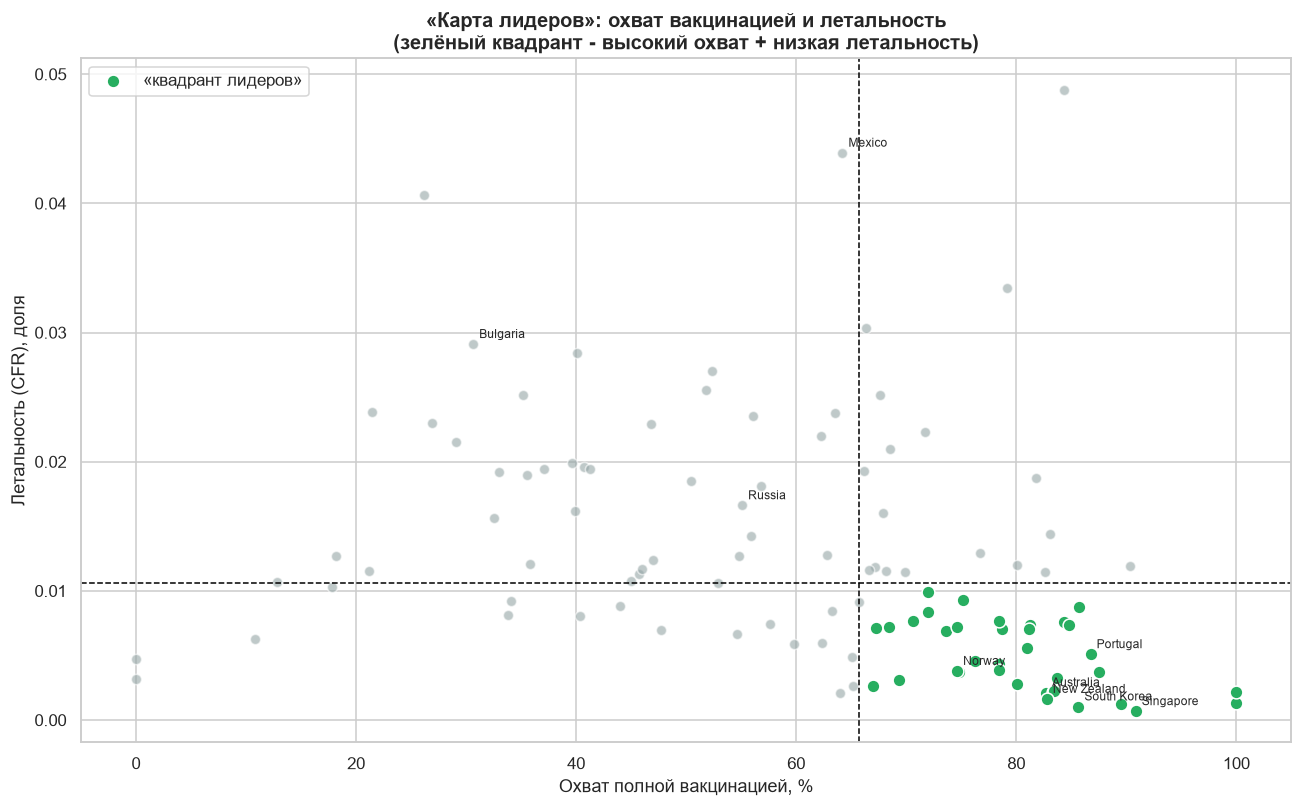

In [125]:
plot_df = reliable[reliable["cfr"] < 0.05]

fig, ax = plt.subplots(figsize=(12, 7.5))
ax.scatter(plot_df["vacc_coverage"], plot_df["cfr"],
           color="#95a5a6", s=45, alpha=0.6, edgecolor="white")

lead_plot = plot_df[(plot_df["vacc_coverage"] > v_med) & (plot_df["cfr"] < c_med)]
ax.scatter(lead_plot["vacc_coverage"], lead_plot["cfr"],
           color="#27ae60", s=70, edgecolor="white", label="«квадрант лидеров»")

ax.axvline(v_med, color="black", linestyle="--", linewidth=1)
ax.axhline(c_med, color="black", linestyle="--", linewidth=1)

for name in ["Singapore", "South Korea", "New Zealand", "Australia",
             "Norway", "Portugal", "Russia", "Mexico", "Bulgaria"]:
    row = plot_df[plot_df["location"] == name]
    if not row.empty:
        ax.annotate(name, (row["vacc_coverage"].values[0], row["cfr"].values[0]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_title("«Карта лидеров»: охват вакцинацией и летальность\n"
             "(зелёный квадрант - высокий охват + низкая летальность)")
ax.set_xlabel("Охват полной вакцинацией, %")
ax.set_ylabel("Летальность (CFR), доля")
ax.legend()
fig.tight_layout()
plt.show()

В квадрате лидеров страны с высоким охватом вакцинации и низкой
летальностью. Среди тех, у кого это сочетается с надёжной статистикой и высоким доходом,
выделяются Сингапур, Южная Корея, Новая Зеландия, Австралия, Япония, Норвегия: они
сочетали быструю массовую вакцинацию с одной из самых низких в мире летальностью.


### 7.2. Ответы на исследовательские вопросы

1. Снизилась ли летальность после вакцинации? Да. Внутри стран медианная летальность упала
   примерно втрое (с 1.8% до 0.7%), снижение почти повсеместно и высокозначимо (H1).
2. Кто лидер? Однозначного лидера нет. По сочетанию признаков выделяются Сингапур, Южная Корея, Новая Зеландия, Австралия.
3. Связан ли уровень вакцинации со смертностью? В сырых данных - парадоксально положительно
   (конфаундинг возрастом и учётом); при контроле этих факторов связь становится отрицательной,
   ожидаемой (H2, H6).
4. Какие внешние факторы определяют исходы? Сильнее всего - возраст населения и полнота
   регистрации смертей; богатство влияет и напрямую, и через доступ к вакцинам (H3, H6).
5. Как это сказалось на экономике? Вакцинация связана с импульсом восстановления 2021 года,
   но не с итоговым двухлетним результатом из-за эффекта отскока (H4).

### 7.3. Сводная таблица гипотез

| Гипотеза | Итог | Ключевая статистика |
|----------|------|---------------------|
| **H1.** CFR снизился после вакцинации (внутри стран) | Подтверждена | Медиана CFR 1.8% - 0.7%; снижение в 126/134; p = 2·10⁻²⁰ |
| **H2.** Выше охват - ниже смертность (сырая) | Отклонена в сыром виде | Спирмен r = +0.37 (конфаундинг) |
| **H3.** Богатые страны вакцинировались активнее | Подтверждена | Спирмен r = +0.57, p < 0.001 |
| **H4.** Вакцинация - восстановление экономики | Частично | Рост 2021: r = +0.23 (значимо); двухлетний: r = 0 |
| **H5.** Зимняя сезонность волн | Частично | Зима выше лета на 40%, но слабее штаммовых волн |
| **H6.** Эффект вакцины при контроле конфаундеров | Подтверждена | Частная корреляция меняет знак: +0.37 - −0.20 |

### 7.4. Главные содержательные выводы

1. Вакцинация измеримо снизила летальность COVID-19 - это самый надёжный результат
   исследования, полученный сравнением стран «до/после» внутри себя.
2. Межстрановые сравнения ьез дополнительного анализа вводят в заблуждение. Возраст населения и полнота учёта
   смертей - настолько сильные конфаундеры, что изначально защитный эффект вакцины не виден и даже
   выглядит обратным. Корректный анализ (контроль конфаундеров, внутристрановые сравнения)
   восстанавливает ожидаемую картину.
3. Динамику пандемии определяла не сезонность, а вмешательство человека. Вакцины и смена
   штаммов перебили естественную сезонность, из-за чего ряд плохо прогнозируется классическими
   методами.
4. Экономический эффект нюансирован: вакцинация дала импульс восстановления, но не
   гарантировала лучший суммарный исход.
